In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
os.chdir('..')

In [3]:
import torch
from sklearn.model_selection import train_test_split
from fq_model.fq_pre_train import FQ
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [5]:
from uci_tests.data import 

X, y = Heart().get_data()
# y = y - 1

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(device)
test_size=0.3
batch_size=63
random_state=990
rules=2
lr=0.0002

cuda


In [13]:
train_accuracies = []
test_accuracies = []

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
X_train = torch.Tensor(X_train).to(device)
X_test = torch.Tensor(X_test).to(device)
y_train = torch.Tensor(y_train).type(torch.LongTensor).to(device)
y_test = torch.Tensor(y_test).type(torch.LongTensor).to(device)

out_size = len(np.unique(y))
print('out_size', out_size)

# Initialize and move model to GPU
model = FQ(in_features=X.shape[1], rules=rules, out_features=out_size, task='classification', fuzzy_model='mamdani').to(device)

out_size 2


In [14]:
import torch.nn as nn

# Set up optimizer and loss function for pre-training
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# Pre-training loop
num_epochs_pretrain = 2000
model.train()
for epoch in range(num_epochs_pretrain):
    total_loss = 0
    for i in range(0, len(X_train), batch_size):
        optimizer.zero_grad()
        batch_X = X_train[i:i+batch_size]
        reconstructed_X = model(batch_X, phase='pretrain')
        loss = loss_fn(reconstructed_X, batch_X)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1}, Pre-training Loss: {total_loss / len(X_test)}')


Epoch 1, Pre-training Loss: 0.06001601219177246
Epoch 2, Pre-training Loss: 0.056158533361223006
Epoch 3, Pre-training Loss: 0.053629998366038004
Epoch 4, Pre-training Loss: 0.05173206859164768
Epoch 5, Pre-training Loss: 0.050136970149146184
Epoch 6, Pre-training Loss: 0.048812704616122776
Epoch 7, Pre-training Loss: 0.04774189790089925
Epoch 8, Pre-training Loss: 0.046846659978230794
Epoch 9, Pre-training Loss: 0.04605666862593757
Epoch 10, Pre-training Loss: 0.045350938373141816
Epoch 11, Pre-training Loss: 0.04471850991249084
Epoch 12, Pre-training Loss: 0.044132222731908165
Epoch 13, Pre-training Loss: 0.04356935289171007
Epoch 14, Pre-training Loss: 0.04302319685618083
Epoch 15, Pre-training Loss: 0.04249092737833659
Epoch 16, Pre-training Loss: 0.04196904765235053
Epoch 17, Pre-training Loss: 0.04145796166525947
Epoch 18, Pre-training Loss: 0.0409601714875963
Epoch 19, Pre-training Loss: 0.0404770486884647
Epoch 20, Pre-training Loss: 0.04001056022114224
Epoch 21, Pre-training L

In [15]:
num_epochs=2000

# Initialize Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in range(num_epochs):
    model.train()
    for i in range(0, len(X_train), batch_size):
        optimizer.zero_grad()
        batch_X, batch_y = X_train[i:i+batch_size], y_train[i:i+batch_size]
        outputs = model(batch_X)
        loss = F.cross_entropy(outputs, batch_y)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        prediction = model(X_test).argmax(dim=1)
        accuracy = accuracy_score(y_test.cpu().numpy(), prediction.cpu().numpy())
        test_accuracies.append(accuracy)
        prediction = model(X_train).argmax(dim=1)
        accuracy = accuracy_score(y_train.cpu().numpy(), prediction.cpu().numpy())
        train_accuracies.append(accuracy)

# Calculate and print the average accuracy across all folds
avg_accuracy = max(test_accuracies)
print("max test accuracy:", avg_accuracy)
avg_accuracy = max(train_accuracies)
print("max train accuracy:", avg_accuracy)

max test accuracy: 0.8888888888888888
max train accuracy: 0.8888888888888888


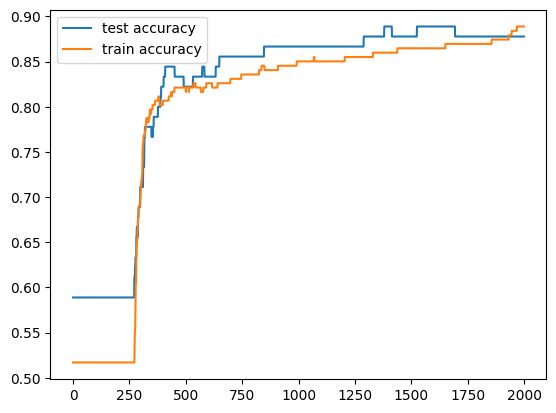

In [16]:
plt.plot(np.arange(len(test_accuracies)), test_accuracies)
plt.plot(np.arange(len(train_accuracies)), train_accuracies)
plt.legend(['test accuracy', 'train accuracy'])
plt.show()

IRIS = 94</br>
Cryotheraphy = 95</br>
Immunotherapy = 89</br>
Haberman = 74</br>
Wine = 89</br>
heart = 85</br>